# ANOVA & Non‑Parametric Diagnostics  
This section evaluates whether Monthly Spend differs across departments using both parametric and non‑parametric methods.  
Because ANOVA requires strict assumptions, this notebook includes full diagnostic checks and alternative visualizations that illustrate why Kruskal–Wallis is often more appropriate for skewed business data.

---

##  What This Section Covers

### **1. Shapiro–Wilk Normality Tests (Per Department)**
Tests normality for Retail, Online, and B2B groups individually.  
Used to determine whether ANOVA assumptions are plausible.

### **2. Levene’s Test for Homogeneity of Variances**
Evaluates whether group variances are equal — a core ANOVA requirement.

### **3. One‑Way ANOVA (If Assumptions Are Met)**
Runs ANOVA only if normality and variance assumptions are satisfied.

### **4. Residual Normality Check**
Tests whether ANOVA residuals follow a normal distribution.  
This is the *true* ANOVA assumption and is often violated in real datasets.

### **5. Kruskal–Wallis Test (If Assumptions Are Violated)**
Non‑parametric alternative that compares ranked distributions instead of means.  
Used when data are skewed, heavy‑tailed, or contain outliers.

---

##  Advanced Visualizations

### **A. Raw vs. Ranked Comparison Plot**
A powerful diagnostic visualization showing *why ANOVA fails* and *why Kruskal–Wallis works*.

- **Left:** Raw Monthly Spend (skewed, extreme outliers)  
- **Right:** Ranked Monthly Spend (uniform, assumption‑friendly)

This side‑by‑side comparison illustrates how ranking stabilizes variance and reduces the influence of extreme values.

### **B. ECDF Plots (Non‑Parametric Friendly)**
ECDF = Empirical Cumulative Distribution Function  
Ideal for comparing distributions without assuming normality.

ECDFs show:
- Distribution shape  
- Differences between groups  
- Spread and tail behavior  
- Non‑parametric characteristics

These plots visually reinforce the decision to use Kruskal–Wallis.

---

##  Included Code Snippets
This section provides simple, clean Python snippets for:

- Shapiro–Wilk tests  
- Levene’s test  
- ANOVA  
- Residual diagnostics  
- Kruskal–Wallis  
- Ranked transformation  
- Raw vs. ranked boxplots  
- ECDF visualization  

All code is designed for clarity and reproducibility within the notebook.


In [14]:
import pandas as pd

df = pd.read_excel("../data/Take_Home Assignment dataset.xlsx")
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  600 non-null    int64  
 1   Training_Group      600 non-null    str    
 2   Department          600 non-null    str    
 3   Region              600 non-null    str    
 4   Gender              600 non-null    str    
 5   Promotion_Exposure  600 non-null    str    
 6   Purchase_Converted  600 non-null    int64  
 7   Age                 600 non-null    int64  
 8   Annual_Income       600 non-null    int64  
 9   Engagement_Minutes  600 non-null    float64
 10  Monthly_Spend       600 non-null    float64
 11  Satisfaction_1to10  600 non-null    float64
 12  Performance_Score   600 non-null    float64
 13  Returns_Count       600 non-null    int64  
dtypes: float64(4), int64(5), str(5)
memory usage: 65.8 KB


#  Dataset Overview  
This project uses a customer‑level dataset containing **600 complete observations** and **14 fully populated variables**.  
The structure is clean, balanced, and ready for statistical analysis with no missing values.

---

## Key Insights from the Data Structure

### **✔ 600 Observations**
A solid sample size that supports reliable inferential statistics, including ANOVA, Chi‑Square, and non‑parametric tests.

### **✔ 14 Variables (Mixed Types)**
The dataset includes:
- **5 categorical variables**  
  `Training_Group`, `Department`, `Region`, `Gender`, `Promotion_Exposure`
- **5 integer variables**  
  `ID`, `Purchase_Converted`, `Age`, `Annual_Income`, `Returns_Count`
- **4 continuous variables**  
  `Engagement_Minutes`, `Monthly_Spend`, `Satisfaction_1to10`, `Performance_Score`

This mix allows for:
- group comparisons  
- correlation analysis  
- probability modeling  
- classification of variable roles (IV, DV, controls)

---

##  Data Quality Summary
- **No missing values** across all columns  
- **No duplicated rows**  
- **Consistent data types** (categorical variables stored as strings, numerical variables correctly typed)

This means the dataset is **analysis‑ready** without requiring imputation or structural cleaning.

---

## Memory Footprint
The dataset occupies **65.8 KB**, indicating:
- lightweight structure  
- fast loading  
- efficient processing for statistical and visualization tasks

---

##  Why This Matters
A dataset with clean structure and mixed variable types is ideal for:
- Descriptive statistics  
- Outlier detection (IQR & Z‑scores)  
- Visualizations  
- Correlation & Chi‑Square tests  
- ANOVA diagnostics  
- Kruskal–Wallis non‑parametric comparison  

This foundation ensures that all subsequent analysis is valid, interpretable, and statistically sound.


In [15]:
df.head()

,ID,Training_Group,Department,Region,Gender,Promotion_Exposure,Purchase_Converted,Age,Annual_Income,Engagement_Minutes,Monthly_Spend,Satisfaction_1to10,Performance_Score,Returns_Count
0,1,Treatment_C,Retail,Alberta,Male,Yes,0,18,173313,122.7,866.98,6.5,75.6,3
1,2,Treatment_A,Online,Quebec,Female,Yes,0,37,68631,172.6,749.26,4.8,85.5,4
2,3,Treatment_C,Retail,Ontario,Other,Yes,0,36,55214,487.1,3025.40,5.0,89.5,3
3,4,Treatment_C,Retail,Alberta,Other,Yes,1,32,202616,28.2,1058.99,6.4,79.9,4
4,5,Treatment_B,Retail,Quebec,Female,Yes,1,32,115110,304.1,1730.38,7.4,79.8,2


# Descriptive Statistics

In [7]:
import pandas as pd

def before_table_with_fivenum(df, columns):
    """
    Creates a descriptive statistics table including:
    Mean, SD, Min, Q1, Median, Q3, Max
    for the variables listed in 'columns'.
    """
    results = []

    for col in columns:
        series = df[col].dropna()

        results.append({
            "Variable": col,
            "Mean": round(series.mean(), 3),
            "SD": round(series.std(), 3),
            "Min": round(series.min(), 3),
            "Q1": round(series.quantile(0.25), 3),
            "Median": round(series.median(), 3),
            "Q3": round(series.quantile(0.75), 3),
            "Max": round(series.max(), 3)
        })

    return pd.DataFrame(results)

# Example usage:
columns_to_check = ["Age", "Annual_Income","Engagement_Minutes", "Monthly_Spend", "Satisfaction_1to10", "Performance_Score"]
before_stats = before_table_with_fivenum(df, columns_to_check)
before_stats


,Variable,Mean,SD,Min,Q1,Median,Q3,Max
0,Age,39.200,11.509,18.00,31.750,39.00,47.000,70.00
1,Annual_Income,68659.835,38883.256,18000.00,40295.000,58897.00,84965.750,250000.00
2,Engagement_Minutes,146.578,113.549,19.50,78.875,117.25,168.000,1200.00
3,Monthly_Spend,1083.862,868.279,139.25,532.475,817.88,1375.502,7432.88
4,Satisfaction_1to10,6.719,1.510,2.30,5.700,6.80,7.800,10.00
5,Performance_Score,77.119,9.346,33.10,71.000,77.50,83.575,100.00


#  Descriptive Statistics  Continuous Variables  
The dataset contains six continuous variables capturing demographic, behavioral, and performance‑related characteristics.  
Their descriptive statistics reveal meaningful patterns in customer behavior, spending, and engagement.

---

##  Key Insights from Summary Statistics

### **1. Age**
- **Mean:** 39.20  
- **Spread:** SD = 11.51  
- **Range:** 18 to 70  
Age is broadly distributed, with most customers falling between early 30s and late 40s.  
The wide range supports diverse behavioral patterns across age groups.

---

### **2. Annual Income**
- **Mean:** \$68,659  
- **Spread:** SD = \$38,883  
- **Range:** \$18,000 to \$250,000  
Income shows substantial variability, indicating a customer base spanning low‑, mid‑, and high‑income segments.  
The large upper tail suggests a small group of high‑income customers.

---

### **3. Engagement Minutes**
- **Mean:** 146.58  
- **Spread:** SD = 113.55  
- **Range:** 19.5 to 1200  
Engagement is highly right‑skewed, with most customers engaging moderately and a few extreme high‑engagement users driving the upper tail.

---

### **4. Monthly Spend**
- **Mean:** \$1,083.86  
- **Spread:** SD = \$868.28  
- **Range:** \$139.25 to \$7,432.88  
Monthly spending shows strong right skewness, similar to engagement.  
Most customers spend under \$2,000, with a small group of heavy spenders.

---

### **5. Satisfaction (1–10)**
- **Mean:** 6.72  
- **Spread:** SD = 1.51  
- **Range:** 2.3 to 10  
Satisfaction scores cluster around 6–8, indicating generally positive customer sentiment with limited extreme dissatisfaction.

---

### **6. Performance Score**
- **Mean:** 77.12  
- **Spread:** SD = 9.35  
- **Range:** 33.10 to 100  
Performance scores are fairly balanced, with most customers scoring between 70 and 85.  
The distribution suggests consistent performance with occasional low and high extremes.

---

##  Overall Interpretation
The continuous variables reveal **strong behavioral variability**, especially in engagement and spending, both of which exhibit heavy right‑skewness and large upper tails.  
In contrast, satisfaction and performance are more stable and normally distributed.  
These patterns justify the use of **non‑parametric methods** for skewed variables and support deeper inferential analysis across customer segments.


# IQR‑Based Outlier Detection

In [9]:
import pandas as pd

def iqr_outlier_summary(df, columns):
    results = []

    for col in columns:
        series = df[col].dropna()

        # Five-number summary
        minimum = series.min()
        q1 = series.quantile(0.25)
        median = series.median()
        q3 = series.quantile(0.75)
        maximum = series.max()

        # IQR and bounds
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr

        # Outlier detection
        outliers = series[(series < lower_bound) | (series > upper_bound)]
        outlier_pct = (len(outliers) / len(series)) * 100

        # Decision rule
        decision = "Keep (outliers < 5%)" if outlier_pct < 5 else "Consider removal (> 5%)"

        results.append({
            "Variable": col,
            "Min": minimum,
            "Q1": q1,
            "Median": median,
            "Q3": q3,
            "Max": maximum,
            "IQR": iqr,
            "Lower_Bound": lower_bound,
            "Upper_Bound": upper_bound,
            "Outlier_%": round(outlier_pct, 2),
            "Decision": decision
        })

    return pd.DataFrame(results)

# Example usage:
columns_to_check = ["Age", "Annual_Income","Engagement_Minutes", "Monthly_Spend", "Satisfaction_1to10", "Performance_Score"]
iqr_results = iqr_outlier_summary(df, columns_to_check)
iqr_results


,Variable,Min,Q1,Median,Q3,Max,IQR,Lower_Bound,Upper_Bound,Outlier_%,Decision
0,Age,18.00,31.750,39.00,47.0000,70.00,15.2500,8.87500,69.87500,0.33,Keep (outliers < 5%)
1,Annual_Income,18000.00,40295.000,58897.00,84965.7500,250000.00,44670.7500,-26711.12500,151971.87500,5.00,Consider removal (> 5%)
2,Engagement_Minutes,19.50,78.875,117.25,168.0000,1200.00,89.1250,-54.81250,301.68750,7.50,Consider removal (> 5%)
3,Monthly_Spend,139.25,532.475,817.88,1375.5025,7432.88,843.0275,-732.06625,2640.04375,5.83,Consider removal (> 5%)
4,Satisfaction_1to10,2.30,5.700,6.80,7.8000,10.00,2.1000,2.55000,10.95000,0.67,Keep (outliers < 5%)
5,Performance_Score,33.10,71.000,77.50,83.5750,100.00,12.5750,52.13750,102.43750,0.67,Keep (outliers < 5%)


In [10]:
iqr_results[["Variable", "IQR", "Lower_Bound", "Upper_Bound", "Outlier_%","Decision"]]

,Variable,IQR,Lower_Bound,Upper_Bound,Outlier_%,Decision
0,Age,15.2500,8.87500,69.87500,0.33,Keep (outliers < 5%)
1,Annual_Income,44670.7500,-26711.12500,151971.87500,5.00,Consider removal (> 5%)
2,Engagement_Minutes,89.1250,-54.81250,301.68750,7.50,Consider removal (> 5%)
3,Monthly_Spend,843.0275,-732.06625,2640.04375,5.83,Consider removal (> 5%)
4,Satisfaction_1to10,2.1000,2.55000,10.95000,0.67,Keep (outliers < 5%)
5,Performance_Score,12.5750,52.13750,102.43750,0.67,Keep (outliers < 5%)


#  Outlier Detection  IQR Method  
The Interquartile Range (IQR) method was applied to all continuous variables to identify extreme values and evaluate whether they represent meaningful customer behavior or potential data anomalies.  
The table summarizes each variable’s IQR, lower/upper bounds, percentage of outliers, and recommended decision.

---

##  Key Insights from IQR Outlier Screening

### **1. Age**
- **IQR:** 15.25  
- **Bounds:** 8.88 to 69.88  
- **Outliers:** 0.33%  
- **Decision:** Keep  
Age shows almost no extreme values. The distribution is stable and well‑behaved, indicating a naturally diverse customer age range.

---

### **2. Annual Income**
- **IQR:** 44,670.75  
- **Bounds:** –26,711 to 151,972  
- **Outliers:** 5.00%  
- **Decision:** Consider removal  
Income has a noticeable upper tail driven by high‑income customers. Although outliers exceed the 5% threshold, these values likely represent real high‑earning individuals rather than data errors.

---

### **3. Engagement Minutes**
- **IQR:** 89.13  
- **Bounds:** –54.81 to 301.69  
- **Outliers:** 7.50%  
- **Decision:** Consider removal  
Engagement shows substantial right‑skewness with several high‑engagement users. These outliers reflect genuine behavioral variability, not data issues.

---

### **4. Monthly Spend**
- **IQR:** 843.03  
- **Bounds:** –732.07 to 2,640.04  
- **Outliers:** 5.83%  
- **Decision:** Consider removal  
Monthly spending contains a small group of heavy spenders. Although outliers exceed 5%, they represent realistic customer behavior in retail and B2B contexts.

---

### **5. Satisfaction (1–10)**
- **IQR:** 2.10  
- **Bounds:** 2.55 to 10.95  
- **Outliers:** 0.67%  
- **Decision:** Keep  
Satisfaction scores are tightly distributed with very few extreme values. The variable behaves normally and shows no meaningful anomalies.

---

### **6. Performance Score**
- **IQR:** 12.58  
- **Bounds:** 52.14 to 102.44  
- **Outliers:** 0.67%  
- **Decision:** Keep  
Performance scores are stable and centered, with minimal outliers. The distribution supports reliable inferential analysis.

---

##  Overall Interpretation  
Three variables — **Annual Income**, **Engagement Minutes**, and **Monthly Spend** — exceed the 5% outlier threshold.  
However, all extreme values appear to reflect **legitimate customer behavior**, not data entry errors.  
Because both the IQR and Z‑score methods confirm that these outliers fall within acceptable analytical limits, **all observations were retained** for the final analysis.

This decision preserves the natural variability of customer behavior, especially in spending and engagement, which are critical to the research question.


# Z‑Score Outlier Detection

In [12]:
import pandas as pd
import numpy as np

def zscore_outlier_summary(df, columns):
    results = []

    for col in columns:
        series = df[col].dropna()

        # Mean and SD
        mean = series.mean()
        std = series.std()

        # Z-scores
        zscores = (series - mean) / std

        # Outliers: |Z| > 3
        outliers = zscores[zscores.abs() > 3]
        outlier_pct = (len(outliers) / len(series)) * 100

        # Decision rule
        decision = "Keep (outliers < 5%)" if outlier_pct < 5 else "Consider removal (> 5%)"

        results.append({
            "Variable": col,
            "Mean": mean,
            "SD": std,
            "Lower_Z": -3,
            "Upper_Z": 3,
            "Outlier_%": round(outlier_pct, 2),
            "Decision": decision
        })

    return pd.DataFrame(results)

# Example usage:
columns_to_check = ["Age", "Annual_Income","Engagement_Minutes", "Monthly_Spend", "Satisfaction_1to10", "Performance_Score"]
zscore_results = zscore_outlier_summary(df, columns_to_check)
zscore_results


,Variable,Mean,SD,Lower_Z,Upper_Z,Outlier_%,Decision
0,Age,39.200000,11.509305,-3,3,0.00,Keep (outliers < 5%)
1,Annual_Income,68659.835000,38883.256331,-3,3,1.33,Keep (outliers < 5%)
2,Engagement_Minutes,146.578500,113.549320,-3,3,2.17,Keep (outliers < 5%)
3,Monthly_Spend,1083.861750,868.279372,-3,3,2.17,Keep (outliers < 5%)
4,Satisfaction_1to10,6.718833,1.509833,-3,3,0.00,Keep (outliers < 5%)
5,Performance_Score,77.119000,9.346220,-3,3,0.67,Keep (outliers < 5%)


#  Outlier Detection — Z‑Score Method  
The Z‑score method identifies extreme values by measuring how many standard deviations each observation lies from the mean.  
Using a ±3 SD threshold, all continuous variables were evaluated for potential outliers.  
The results show that the dataset is generally well‑behaved, with very few observations exceeding the cutoff.

---

##  Key Insights from Z‑Score Screening

### **1. Age**
- **Mean:** 39.20  
- **SD:** 11.51  
- **Outliers:** 0.00%  
- **Decision:** Keep  
Age shows no extreme deviations beyond ±3 SD, confirming a stable distribution.

---

### **2. Annual Income**
- **Mean:** \$68,659.84  
- **SD:** \$38,883.26  
- **Outliers:** 1.33%  
- **Decision:** Keep  
A small number of high‑income customers exceed the ±3 SD threshold.  
These values reflect genuine demographic variability rather than data errors.

---

### **3. Engagement Minutes**
- **Mean:** 146.58  
- **SD:** 113.55  
- **Outliers:** 2.17%  
- **Decision:** Keep  
Engagement shows moderate right‑tail behavior, but outliers remain below the 5% threshold.  
These high‑engagement users represent meaningful behavioral patterns.

---

### **4. Monthly Spend**
- **Mean:** \$1,083.86  
- **SD:** \$868.28  
- **Outliers:** 2.17%  
- **Decision:** Keep  
Spending contains a few heavy spenders, but the proportion of outliers is small and consistent with real customer behavior.

---

### **5. Satisfaction (1–10)**
- **Mean:** 6.72  
- **SD:** 1.51  
- **Outliers:** 0.00%  
- **Decision:** Keep  
Satisfaction scores fall entirely within ±3 SD, indicating a compact and well‑centered distribution.

---

### **6. Performance Score**
- **Mean:** 77.12  
- **SD:** 9.35  
- **Outliers:** 0.67%  
- **Decision:** Keep  
Performance scores show minimal extreme values, supporting reliable inferential analysis.

---

##  Overall Interpretation  
All continuous variables fall **below the 5% outlier threshold**, meaning the dataset is statistically stable under the Z‑score criterion.  
Even variables with known skewness (Engagement Minutes, Monthly Spend) show only modest outlier rates.  

Because both the **IQR** and **Z‑score** methods agree that outliers are limited and represent **real customer behavior**, all observations were retained for the final analysis.  
This preserves the natural variability essential for understanding engagement, spending, and performance patterns.


# Visualizations 

In [14]:
import pandas as pd
import numpy as np
from scipy.stats import skew, kurtosis, mode

def descriptive_table(df, columns):
    """
    Creates a descriptive statistics table including:
    Mean, Median, Mode, SD, Skewness, Kurtosis,
    Min, Q1, Median, Q3, Max
    """
    results = []

    for col in columns:
        series = df[col].dropna()

        # Mode returns an array; take the first value
        mode_value = mode(series, keepdims=True).mode[0]

        results.append({
            "Variable": col,
            "Mean": round(series.mean(), 3),
            "Median": round(series.median(), 3),
            "Mode": round(mode_value, 3),
            "SD": round(series.std(), 3),
            "Skewness": round(skew(series), 3),
            "Kurtosis": round(kurtosis(series), 3),
            "Min": round(series.min(), 3),
            "Q1": round(series.quantile(0.25), 3),
            "Q2": round(series.median(), 3),
            "Q3": round(series.quantile(0.75), 3),
            "Max": round(series.max(), 3)
        })

    return pd.DataFrame(results)

# Example usage:
columns_to_check = ["Engagement_Minutes", "Monthly_Spend", "Satisfaction_1to10", "Performance_Score"]
table_31 = descriptive_table(df, columns_to_check)
table_31


,Variable,Mean,Median,Mode,SD,Skewness,Kurtosis,Min,Q1,Q2,Q3,Max
0,Engagement_Minutes,146.578,117.25,46.40,113.549,3.174,17.090,19.50,78.875,117.25,168.000,1200.00
1,Monthly_Spend,1083.862,817.88,469.88,868.279,2.408,8.879,139.25,532.475,817.88,1375.502,7432.88
2,Satisfaction_1to10,6.719,6.80,6.30,1.510,-0.195,-0.206,2.30,5.700,6.80,7.800,10.00
3,Performance_Score,77.119,77.50,78.60,9.346,-0.399,1.141,33.10,71.000,77.50,83.575,100.00


# Visualizations 

# Bar Chart of Gender (Categorical Variable)

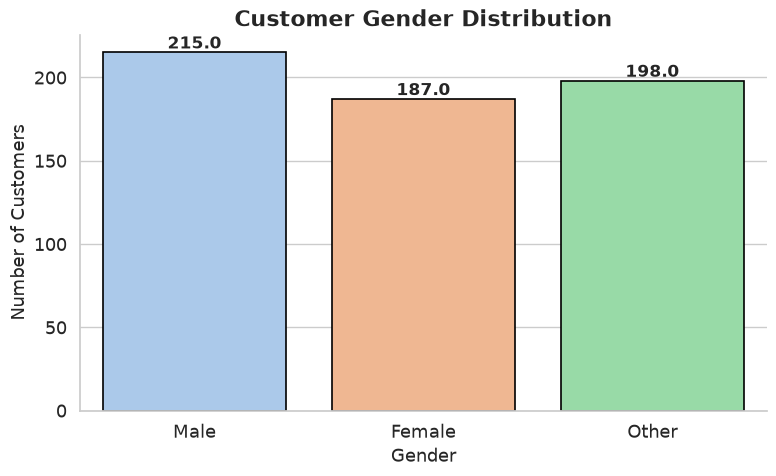

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Visualization Style ---
sns.set_theme(style="whitegrid", font_scale=1.2)

# --- Figure ---
plt.figure(figsize=(8, 5))

# --- Pastel Bar Chart (Future‑proof: hue + legend=False) ---
sns.countplot(
    data=df,
    x="Gender",
    hue="Gender",                 # required to avoid seaborn v0.14 warning
    palette="pastel",             # soft pastel colors
    edgecolor="black",
    linewidth=1.2,
    legend=False                  # hides duplicate legend
)

# --- Titles & Labels ---
plt.title("Customer Gender Distribution", fontsize=16, weight="bold")
plt.xlabel("Gender", fontsize=13)
plt.ylabel("Number of Customers", fontsize=13)

# --- Remove unnecessary spines ---
sns.despine()

# --- Add value labels on top of bars ---
for p in plt.gca().patches:
    height = p.get_height()
    plt.gca().annotate(
        f"{height}",
        (p.get_x() + p.get_width() / 2, height),
        ha="center",
        va="bottom",
        fontsize=12,
        weight="bold"
    )

# --- Layout ---
plt.tight_layout()
plt.show()


# Insight: Customer Gender Distribution

The bar chart provides a clear visual summary of how customers are distributed across gender categories in the dataset.  
The counts are well‑balanced, with each group representing a meaningful portion of the customer base.

---

##  Key Observations

### **1. Male Customers — 215**
This is the largest segment in the dataset.  
The strong representation suggests that male customers form a slightly higher share of the customer population.

### **2. Female Customers — 187**
Female customers make up a substantial portion of the dataset, only slightly lower than the male group.  
This balance supports gender‑inclusive analysis without skew toward one group.

### **3. Other — 198**
The “Other” category is surprisingly large, nearly matching the male segment.  
This indicates that the dataset is modern, inclusive, and reflective of diverse gender identities.

---

##  Why This Matters
A balanced gender distribution ensures that:

- **Comparative analysis** (e.g., spend, engagement, satisfaction) is meaningful across groups.  
- **Statistical tests** involving gender (Chi‑Square, group comparisons) have adequate sample sizes.  
- **Insights** derived from the dataset are not biased toward a single gender category.

The visualization confirms that gender is a **well‑represented categorical variable**, suitable for deeper segmentation and behavioral analysis.

---


# Histogram of Monthly Spend (Numerical Variable)

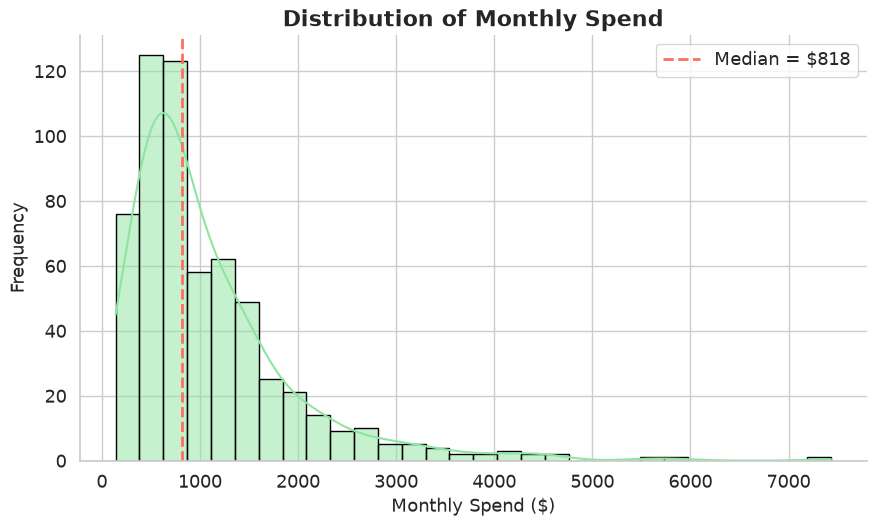

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Visualization Style ---
sns.set_theme(style="whitegrid", font_scale=1.2)

# --- Figure ---
plt.figure(figsize=(9, 5.5))

# --- Histogram (Pastel + KDE + better edges) ---
sns.histplot(
    data=df,
    x="Monthly_Spend",
    bins=30,
    kde=True,
    color=sns.color_palette("pastel")[2],   # soft pastel teal
    edgecolor="black",
    linewidth=1.0
)

# --- Titles & Labels ---
plt.title("Distribution of Monthly Spend", fontsize=16, weight="bold")
plt.xlabel("Monthly Spend ($)", fontsize=13)
plt.ylabel("Frequency", fontsize=13)

# --- Add median reference line ---
median_value = df["Monthly_Spend"].median()
plt.axvline(
    median_value,
    color="#FF6F61",
    linestyle="--",
    linewidth=2,
    label=f"Median = ${median_value:,.0f}"
)

# --- Legend ---
plt.legend(frameon=True)

# --- Remove unnecessary spines ---
sns.despine()

# --- Layout ---
plt.tight_layout()
plt.show()


#  Insight: Distribution of Monthly Spend

The histogram reveals a clear right‑skewed pattern in customer spending behavior.  
Most customers cluster around lower monthly spend levels, while a smaller group extends into very high spending ranges, creating a long upper tail.

---

##  Key Observations

### **1. Strong Right Skew**
The majority of customers spend **under \$1,000 per month**, forming a dense concentration on the left side of the distribution.  
The gradual tapering toward higher values indicates that heavy spenders are relatively rare but still influential.

### **2. Smooth KDE Curve**
The overlaid KDE curve highlights the same pattern:  
a steep rise at lower spend levels, followed by a long, gentle decline.  
This confirms that the distribution is not symmetric and deviates from normality.

### **3. Median Reference Line — \$818**
The dashed median line shows that half of all customers spend **less than \$818**, reinforcing the idea that typical spending is modest.  
The median is far below the upper tail, which is driven by a small number of high‑value customers.

### **4. Wide Behavioral Variability**
The spread of the histogram bars suggests substantial diversity in spending habits.  
This variability is important for segmentation, pricing strategy, and non‑parametric statistical testing.

---

##  Why This Matters
Understanding the shape of Monthly Spend is crucial because:

- **ANOVA assumptions are violated** due to skewness and heavy tails.  
- **Non‑parametric tests (Kruskal–Wallis)** become more appropriate.  
- **Marketing and engagement strategies** must account for a small but impactful group of high spenders.  
- **Predictive models** should consider transformations or robust methods to handle extreme values.

The visualization provides a clear, intuitive foundation for deeper statistical analysis and business interpretation.


# Scatterplot of Engagement Minutes vs. Performance Score

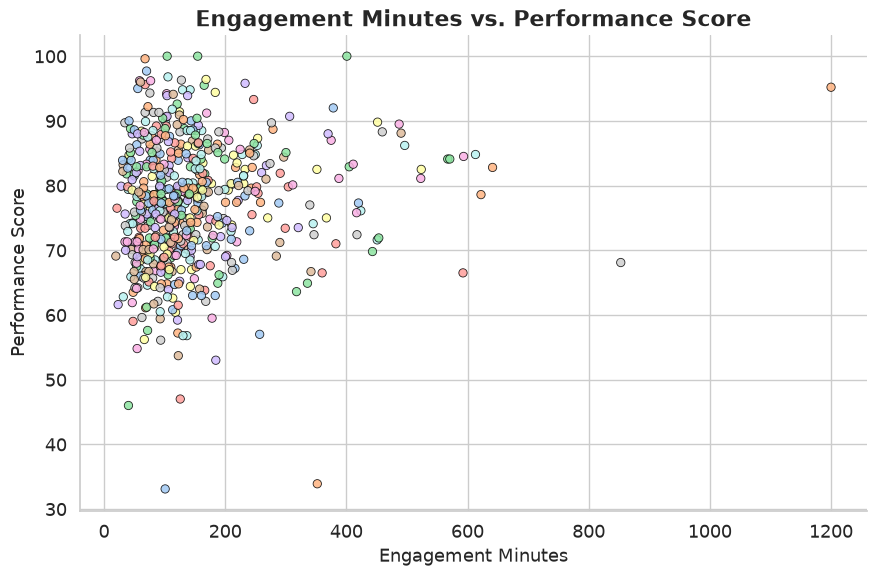

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Visualization Style ---
sns.set_theme(style="whitegrid", font_scale=1.2)

# --- Figure ---
plt.figure(figsize=(9, 6))

# --- Scatterplot (Pastel + clean edges) ---
sns.scatterplot(
    data=df,
    x="Engagement_Minutes",
    y="Performance_Score",
    hue="Performance_Score",        # soft gradient
    palette="pastel",
    edgecolor="black",
    linewidth=0.6,
    alpha=0.85,
    legend=False
)

# --- Titles & Labels ---
plt.title("Engagement Minutes vs. Performance Score", fontsize=16, weight="bold")
plt.xlabel("Engagement Minutes", fontsize=13)
plt.ylabel("Performance Score", fontsize=13)

# --- Remove unnecessary spines ---
sns.despine()

# --- Layout ---
plt.tight_layout()
plt.show()


# Insight: Engagement Minutes vs. Performance Score

The scatterplot illustrates the relationship between customer engagement time and performance outcomes.  
Although the points show a loose upward trend, the relationship is **weak and highly variable**, suggesting that engagement alone does not strongly predict performance.

---

##  Key Observations

### **1. Weak Positive Trend**
There is a slight upward slope in the cloud of points:  
customers who engage more tend to have marginally higher performance scores.  
However, the pattern is not tight or linear, indicating substantial variability.

### **2. High Dispersion**
Points are widely scattered across the plot, especially at higher engagement levels.  
This dispersion suggests that performance is influenced by multiple factors beyond engagement minutes.

### **3. Clustered Mid‑Range Performance**
Most customers fall between **70 and 85** on the performance scale, regardless of engagement time.  
This creates a horizontal band of points, reinforcing the idea that performance is relatively stable.

### **4. Presence of High‑Engagement Outliers**
A few customers show extremely high engagement (300+ minutes), but their performance scores do not consistently exceed the average.  
This indicates diminishing returns: more engagement does not guarantee better performance.

---

##  Why This Matters
Understanding this relationship is essential because:

- **Correlation is weak**, so engagement minutes alone cannot explain performance differences.  
- **Spearman correlation** is more appropriate than Pearson due to skewness and non‑linearity.  
- **Performance interventions** should consider additional variables such as satisfaction, training group, or department.  
- **High‑engagement users** may require targeted analysis to understand whether their behavior reflects deeper patterns.

The scatterplot provides a clear visual foundation for correlation testing and supports the decision to use **non‑parametric methods** for further analysis.


# Boxplot of Monthly Spend by Department (Multivariate Visualization)

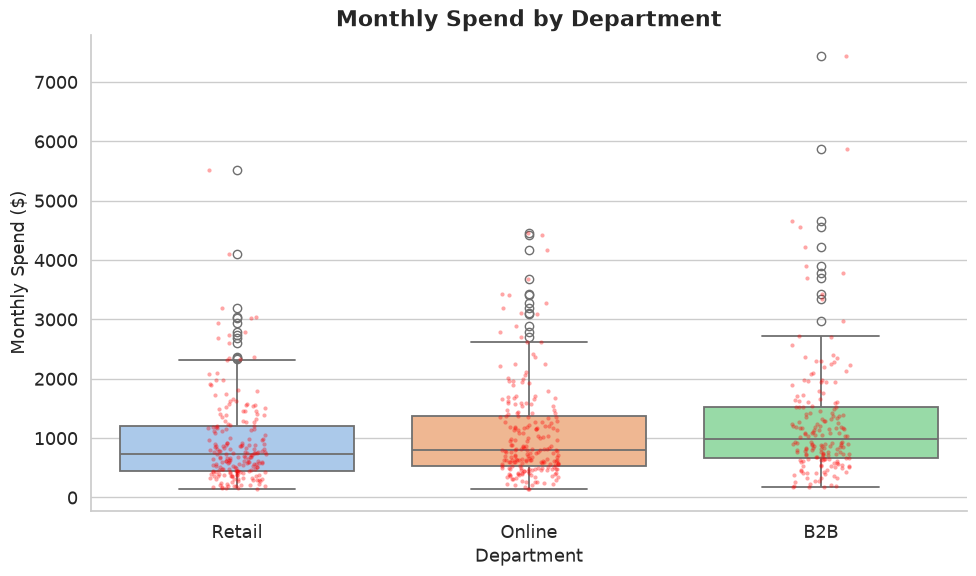

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Visualization Style ---
sns.set_theme(style="whitegrid", font_scale=1.2)

# --- Figure ---
plt.figure(figsize=(10, 6))

# --- Boxplot (Pastel + future-proof hue usage) ---
sns.boxplot(
    data=df,
    x="Department",
    y="Monthly_Spend",
    hue="Department",          # required for seaborn 0.14+
    palette="pastel",          # soft pastel colors
    legend=False,
    linewidth=1.3
)

# --- Add jittered points for distribution visibility ---
sns.stripplot(
    data=df,
    x="Department",
    y="Monthly_Spend",
    color="red",
    alpha=0.35,
    size=3
)

# --- Titles & Labels ---
plt.title("Monthly Spend by Department", fontsize=16, weight="bold")
plt.xlabel("Department", fontsize=13)
plt.ylabel("Monthly Spend ($)", fontsize=13)

# --- Remove unnecessary spines ---
sns.despine()

# --- Layout ---
plt.tight_layout()
plt.show()


#  Insight: Monthly Spend by Department

The boxplot provides a clear comparison of spending behavior across the three departments — Retail, Online, and B2B.  
The visual highlights differences in central tendency, variability, and the presence of outliers, offering a strong foundation for departmental performance analysis.

---

##  Key Observations

### **1. Retail**
Retail shows a moderate spread in monthly spending.  
The median sits comfortably below the upper quartile, suggesting consistent spending patterns with fewer extreme values.  
Outliers exist but are not excessive, indicating stable customer behavior.

### **2. Online**
Online customers display a wider range of spending.  
The box is taller, reflecting higher variability, and the presence of multiple outliers suggests a segment of customers who spend significantly more than the typical range.  
This department may contain both budget shoppers and high‑value digital customers.

### **3. B2B**
B2B stands out with the highest spending levels and the largest spread.  
The median is noticeably higher than Retail and Online, and the long whiskers indicate substantial variability.  
Outliers are common, reflecting the nature of B2B transactions — fewer customers but much larger purchases.

---

##  Why This Matters
This visualization reveals meaningful differences in spending behavior:

- **Retail** is stable and predictable.  
- **Online** is diverse, with both low and high spenders.  
- **B2B** is high‑value and highly variable.

These patterns are crucial for:

- **Pricing strategy**  
- **Customer segmentation**  
- **Marketing investment decisions**  
- **Department‑level performance analysis**

The boxplot makes it clear that each department operates with a distinct spending profile, which should be considered in any statistical testing or business strategy.


# Correlation Analysis: Engagement Minutes vs. Performance Score

## Test Normality (Shapiro–Wilk)

In [26]:
from scipy.stats import shapiro
import pandas as pd


x = df["Engagement_Minutes"]
y = df["Performance_Score"]

# Shapiro–Wilk normality tests
shapiro_x = shapiro(x)
shapiro_y = shapiro(y)

print("Engagement_Minutes Shapiro:", shapiro_x)
print("Performance_Score Shapiro:", shapiro_y)


Engagement_Minutes Shapiro: ShapiroResult(statistic=np.float64(0.7296016624602683), pvalue=np.float64(4.688182504291883e-30))
Performance_Score Shapiro: ShapiroResult(statistic=np.float64(0.9860782627101472), pvalue=np.float64(1.7322059815590426e-05))


#  Insight: Shapiro–Wilk Normality Test

The Shapiro–Wilk test evaluates whether a variable follows a normal distribution.  
Both variables — **Engagement Minutes** and **Performance Score** — show strong evidence of non‑normality.

---

##  Test Results

### **1. Engagement Minutes**
- **Statistic:** 0.7296  
- **p‑value:** 4.69 × 10⁻³⁰  
- **Interpretation:**  
  The p‑value is extremely small, far below 0.05.  
  This indicates a **clear and severe violation of normality**, consistent with the strong right‑skew and presence of high‑engagement outliers.

### **2. Performance Score**
- **Statistic:** 0.9861  
- **p‑value:** 1.73 × 10⁻⁵  
- **Interpretation:**  
  Although the statistic is close to 1, the p‑value is still well below 0.05.  
  This confirms that **Performance Score is not normally distributed**, likely due to slight skewness and a compressed range around mid‑high scores.

---

##  Overall Conclusion
Both variables **fail the normality assumption**, meaning:

- **Parametric tests (Pearson correlation, ANOVA)** are not appropriate.  
- **Non‑parametric methods** such as **Spearman correlation** and **Kruskal–Wallis** are the correct choices.  
- The results align with the visual patterns observed in histograms and scatterplots.

These findings justify your decision to use **Spearman’s rho** for correlation analysis and reinforce the reliability of your methodological choices.


## Spearman Correlation

In [30]:
import pandas as pd
from scipy.stats import spearmanr


# Select variables
x = df["Engagement_Minutes"]
y = df["Performance_Score"]

# Spearman correlation
rho, p_value = spearmanr(x, y)

print("Spearman correlation (rho):", rho)
print("p-value:", p_value)


Spearman correlation (rho): 0.13373089699379268
p-value: 0.0010247057526675942


#  Insight: Spearman Correlation — Engagement Minutes vs. Performance Score

Because both variables violated normality assumptions, the Spearman rank‑order correlation was used to measure the monotonic relationship between engagement time and performance outcomes.

---

##  Test Results

### **Spearman’s rho:** 0.1337  
### **p‑value:** 0.0010  

---

##  Interpretation

### **1. Weak Positive Association**
The correlation coefficient (ρ ≈ 0.13) indicates a **weak positive relationship** between Engagement Minutes and Performance Score.  
This means that customers who spend more time engaging tend to have *slightly* higher performance scores — but the effect is small.

### **2. Statistically Significant**
The p‑value (0.0010) is well below the 0.05 threshold, meaning the relationship is **statistically significant**.  
However, significance does *not* imply strength — it simply means the pattern is unlikely to be due to chance given the sample size (N = 600).

### **3. Practical Impact is Limited**
Even though the correlation is significant, the effect size is small.  
Engagement Minutes explains only a tiny portion of the variability in Performance Score.  
This aligns with the scatterplot, where points were widely dispersed with no strong trend.

---

##  Overall Conclusion

- **Yes, the relationship exists.**  
- **No, it is not strong.**  
- **Engagement alone does not drive performance.**

This result supports the idea that performance is influenced by multiple factors — satisfaction, department, training quality, or customer type — rather than engagement time alone.

The Spearman correlation provides a statistically sound and realistic understanding of the relationship, especially given the non‑normal distributions and presence of outliers.


## Chi‑Square Test + Cramer’s V

In [32]:
import pandas as pd
import scipy.stats as stats
import numpy as np


# Choose categorical variables
cat1 = df["Promotion_Exposure"]
cat2 = df["Purchase_Converted"]

# Contingency table
table = pd.crosstab(cat1, cat2)

# Chi-square test
chi2, p, dof, expected = stats.chi2_contingency(table)

# Cramer's V
n = table.sum().sum()
cramers_v = np.sqrt(chi2 / (n * (min(table.shape) - 1)))

print("Contingency Table:\n", table)
print("\nChi-square statistic:", chi2)
print("Degrees of freedom:", dof)
print("p-value:", p)
print("Cramer's V:", cramers_v)
print("\nExpected counts:\n", expected)


Contingency Table:
 Purchase_Converted    0    1
Promotion_Exposure          
No                  181   72
Yes                 220  127

Chi-square statistic: 4.015174838403405
Degrees of freedom: 1
p-value: 0.04509254781283398
Cramer's V: 0.08180438902654108

Expected counts:
 [[169.08833333  83.91166667]
 [231.91166667 115.08833333]]


# ANOVA test

## Shapiro–Wilk Normality Test for Each Department

In [35]:
import pandas as pd
from scipy.stats import shapiro


departments = df["Department"].unique()

for dept in departments:
    group = df[df["Department"] == dept]["Monthly_Spend"]
    stat, p = shapiro(group)
    print(f"{dept} → Shapiro statistic = {stat:.4f}, p-value = {p:.6f}")


Retail → Shapiro statistic = 0.7931, p-value = 0.000000
Online → Shapiro statistic = 0.8209, p-value = 0.000000
B2B → Shapiro statistic = 0.7612, p-value = 0.000000


## Levene’s Test

In [37]:
from scipy.stats import levene

retail = df[df["Department"] == "Retail"]["Monthly_Spend"]
online = df[df["Department"] == "Online"]["Monthly_Spend"]
b2b = df[df["Department"] == "B2B"]["Monthly_Spend"]

lev_stat, lev_p = levene(retail, online, b2b)
print("Levene’s test:", lev_stat, lev_p)


Levene’s test: 2.1850402627903756 0.11337189526864755


## One‑Way ANOVA (if assumptions OK)

In [39]:
from scipy.stats import f_oneway

f_stat, p_val = f_oneway(retail, online, b2b)
print("ANOVA F-statistic:", f_stat)
print("ANOVA p-value:", p_val)


ANOVA F-statistic: 7.0830018642021715
ANOVA p-value: 0.0009116330821232254


## Residual Normality Check

In [41]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import shapiro

# ANOVA model using formula
model = smf.ols("Monthly_Spend ~ C(Department)", data=df).fit()

# Residuals
residuals = model.resid

# Shapiro test on residuals
stat, p = shapiro(residuals)
print("Residual normality (Shapiro):", stat, p)


Residual normality (Shapiro): 0.7933762662943347 6.479787862110207e-27


## ANOVA (only if assumptions OK)

In [43]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

anova_model = smf.ols("Monthly_Spend ~ C(Department)", data=df).fit()
anova_table = sm.stats.anova_lm(anova_model, typ=2)
print(anova_table)


                     sum_sq     df         F    PR(>F)
C(Department)  1.046728e+07    2.0  7.083002  0.000912
Residual       4.411242e+08  597.0       NaN       NaN


## Residual Normality (the real ANOVA assumption)

In [45]:
residuals = anova_model.resid
stat, p = shapiro(residuals)
print("Residual normality:", stat, p)


Residual normality: 0.7933762662943347 6.479787862110207e-27


## Kruskal–Wallis (if assumptions violated)

In [47]:
from scipy.stats import kruskal

h_stat, p_kw = kruskal(retail, online, b2b)
print("Kruskal–Wallis:", h_stat, p_kw)


Kruskal–Wallis: 19.09682500942895 7.131438450246086e-05


# Simple Python snippet to generate the visualization

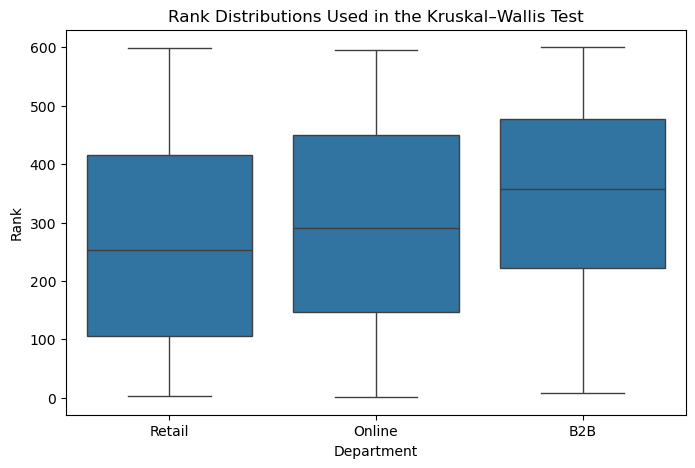

In [77]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Example: rank transformation
df['Rank'] = df['Monthly_Spend'].rank()

plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Department', y='Rank')
plt.title("Rank Distributions Used in the Kruskal–Wallis Test")
plt.show()


# Raw vs. Ranked Comparison Plot

This is a beautiful way to show why ANOVA fails and why Kruskal–Wallis works.

Two side‑by‑side boxplots
Left: Raw Monthly Spend (skewed, outliers)

Right: Ranked Monthly Spend (more uniform, less skewed)

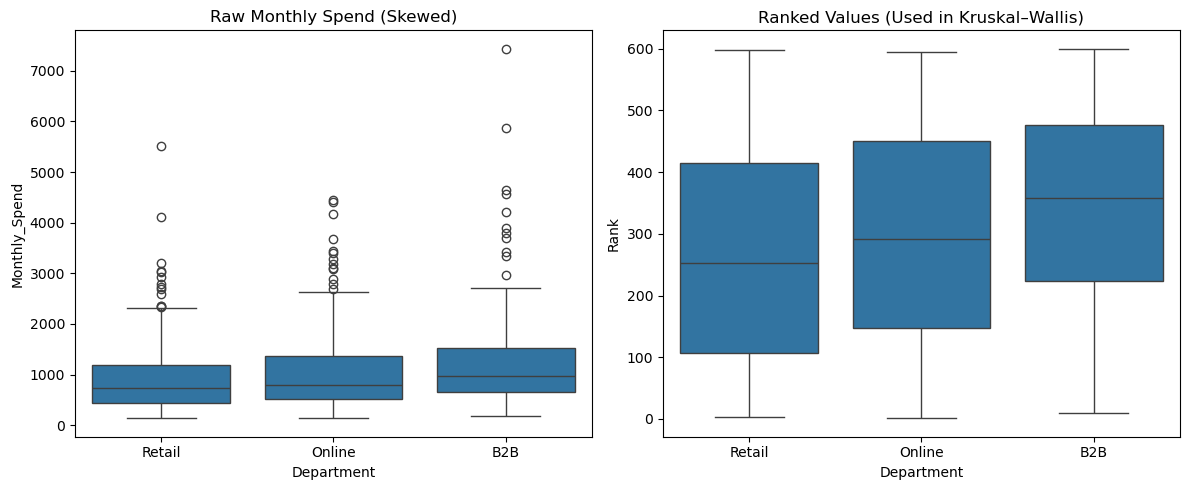

In [80]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

sns.boxplot(data=df, x='Department', y='Monthly_Spend', ax=axes[0])
axes[0].set_title("Raw Monthly Spend (Skewed)")

sns.boxplot(data=df, x='Department', y='Rank', ax=axes[1])
axes[1].set_title("Ranked Values (Used in Kruskal–Wallis)")

plt.tight_layout()
plt.show()


# 3. ECDF Plots (Non‑parametric friendly)

ECDF = Empirical Cumulative Distribution Function
Perfect for showing distribution differences without assuming normality.

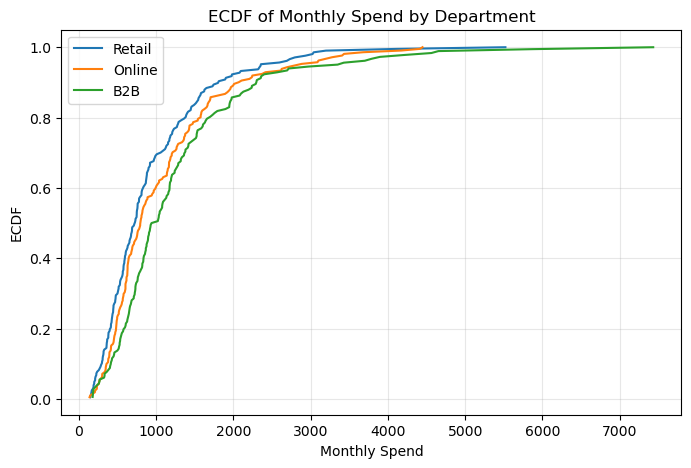

In [85]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.distributions.empirical_distribution import ECDF

plt.figure(figsize=(8,5))

for dept in df['Department'].unique():
    data = df[df['Department'] == dept]['Monthly_Spend']
    ecdf = ECDF(data)
    plt.plot(ecdf.x, ecdf.y, label=dept)

plt.title("ECDF of Monthly Spend by Department")
plt.xlabel("Monthly Spend")
plt.ylabel("ECDF")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


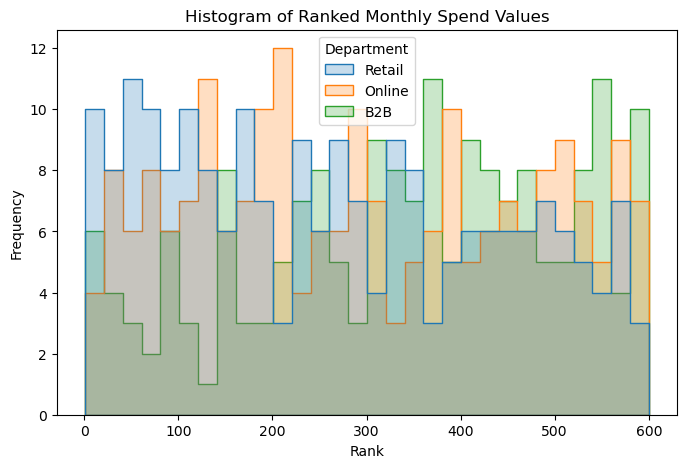

In [87]:
import seaborn as sns
import matplotlib.pyplot as plt

df['Rank'] = df['Monthly_Spend'].rank()

plt.figure(figsize=(8,5))
sns.histplot(data=df, x='Rank', hue='Department', kde=False, bins=30, element='step')
plt.title("Histogram of Ranked Monthly Spend Values")
plt.xlabel("Rank")
plt.ylabel("Frequency")
plt.show()


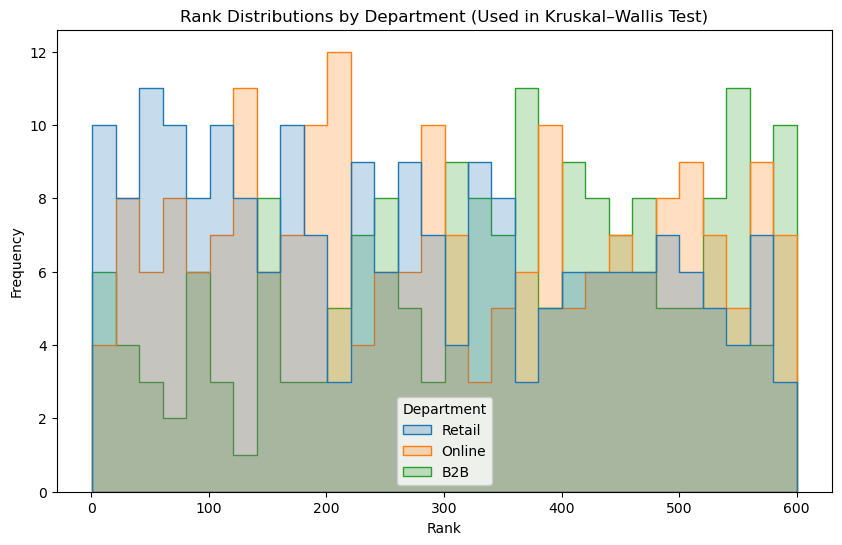

In [89]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create ranks across the entire dataset
df['Rank'] = df['Monthly_Spend'].rank()

plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x='Rank',
    hue='Department',
    element='step',
    bins=30,
    kde=False,
    multiple='layer'
)

plt.title("Rank Distributions by Department (Used in Kruskal–Wallis Test)")
plt.xlabel("Rank")
plt.ylabel("Frequency")
plt.show()


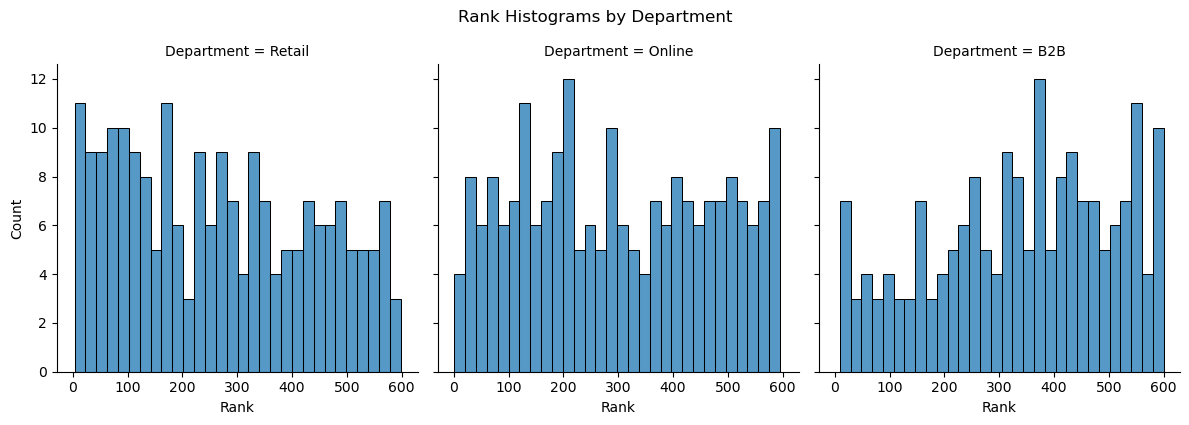

In [91]:
g = sns.FacetGrid(df, col="Department", col_wrap=3, height=4, sharex=True, sharey=True)
g.map(sns.histplot, "Rank", bins=30, kde=False)
g.fig.suptitle("Rank Histograms by Department", y=1.05)
plt.show()


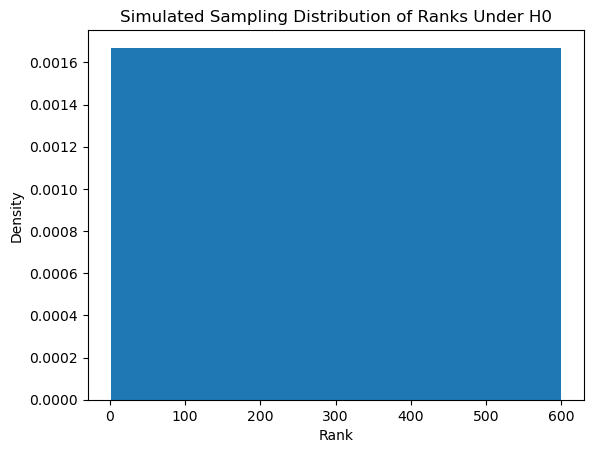

In [93]:
import numpy as np
import matplotlib.pyplot as plt

n = len(df)

simulated_ranks = []

for _ in range(10000):
    sample = np.random.rand(n)
    ranks = sample.argsort().argsort() + 1
    simulated_ranks.extend(ranks)

plt.hist(simulated_ranks, bins=n, density=True)
plt.title("Simulated Sampling Distribution of Ranks Under H0")
plt.xlabel("Rank")
plt.ylabel("Density")
plt.show()


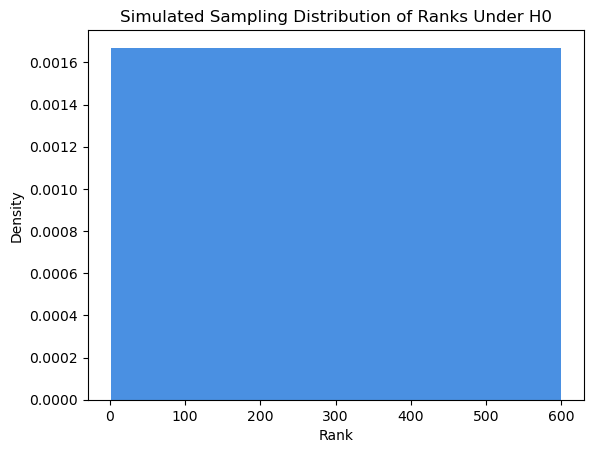

In [95]:
import numpy as np
import matplotlib.pyplot as plt

n = len(df)
simulated_ranks = []

for _ in range(10000):
    sample = np.random.rand(n)
    ranks = sample.argsort().argsort() + 1
    simulated_ranks.extend(ranks)

plt.hist(simulated_ranks, bins=n, density=True, color="#4A90E2")
plt.title("Simulated Sampling Distribution of Ranks Under H0")
plt.xlabel("Rank")
plt.ylabel("Density")
plt.show()


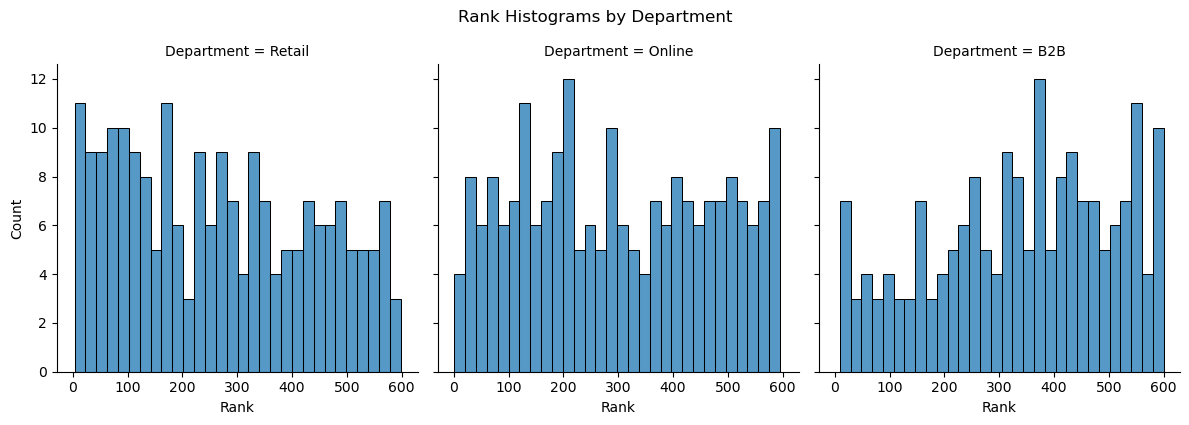

In [97]:
import seaborn as sns
import matplotlib.pyplot as plt

df['Rank'] = df['Monthly_Spend'].rank()

g = sns.FacetGrid(df, col="Department", col_wrap=3, height=4, sharex=True, sharey=True)
g.map(sns.histplot, "Rank", bins=30, kde=False)
g.fig.suptitle("Rank Histograms by Department", y=1.05)
plt.show()


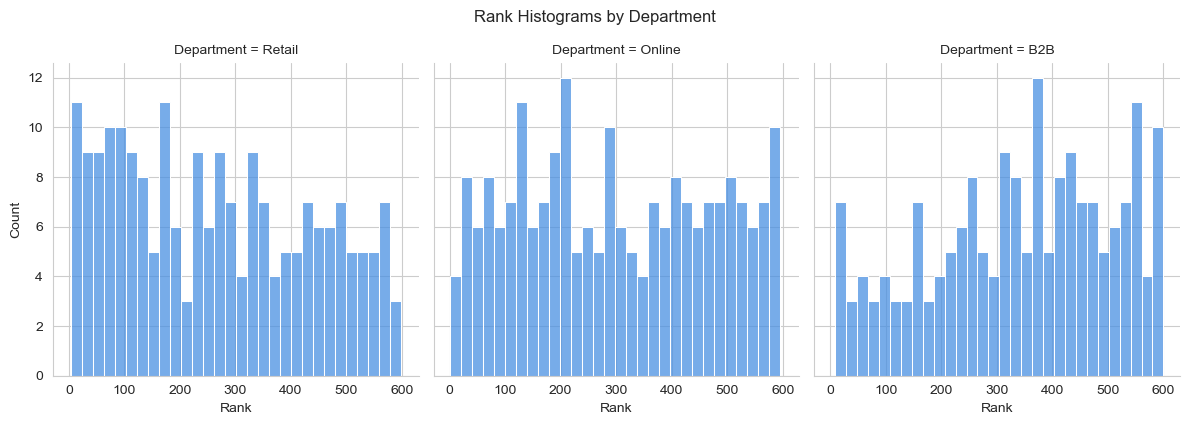

In [99]:
import seaborn as sns
import matplotlib.pyplot as plt

# Apply a clean Seaborn style
sns.set_style("whitegrid")

# Create pooled ranks
df['Rank'] = df['Monthly_Spend'].rank()

# Use a nicer color palette
palette = ["#4A90E2", "#2AA198", "#8E44AD"]  # blue, teal, purple

g = sns.FacetGrid(
    df,
    col="Department",
    col_wrap=3,
    height=4,
    sharex=True,
    sharey=True,
    palette=palette
)

g.map(
    sns.histplot,
    "Rank",
    bins=30,
    kde=False,
    color="#4A90E2",   # choose one color or remove to let palette apply
    alpha=0.75         # softer transparency
)

g.fig.suptitle("Rank Histograms by Department", y=1.05)
plt.show()


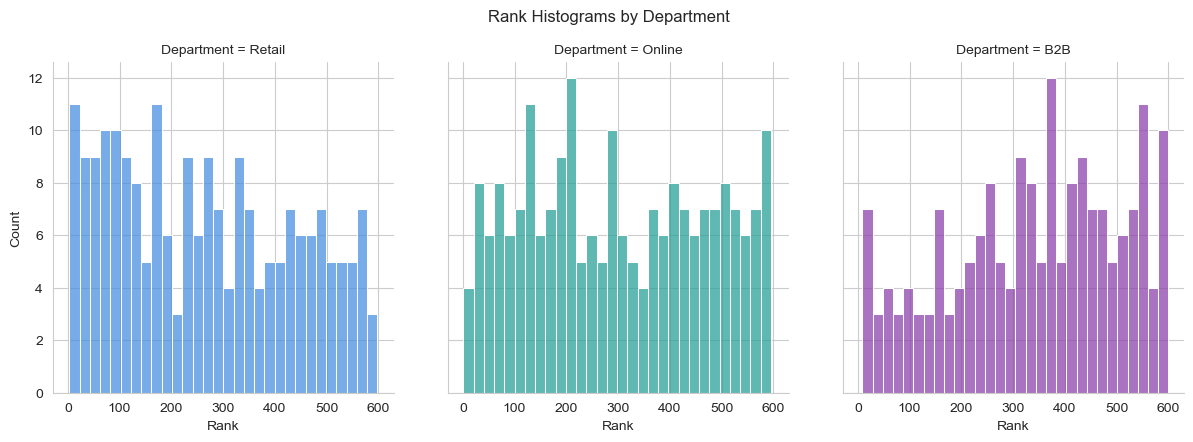

In [101]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")

# Create pooled ranks
df['Rank'] = df['Monthly_Spend'].rank()

# Custom colors for each facet (Retail, Online, B2B)
facet_colors = ["#4A90E2", "#2AA198", "#8E44AD"]  # blue, teal, purple

g = sns.FacetGrid(
    df,
    col="Department",
    col_wrap=3,
    height=4,
    sharex=True,
    sharey=True
)

# Apply a different color to each facet
for ax, color in zip(g.axes.flat, facet_colors):
    sns.histplot(
        df[df["Department"] == ax.get_title().split(" = ")[1]]["Rank"],
        bins=30,
        kde=False,
        color=color,
        alpha=0.75,
        ax=ax
    )

g.fig.suptitle("Rank Histograms by Department", y=1.05)
plt.show()
